# QUESTION 1: Age & Gender Distribution of Donors

In [ ]:
# QUESTION 1: Age & Gender Distribution of Donors

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Load the preprocessed data
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx", sheet_name="Preprocessed_Data")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Age & Gender Distribution of Donors', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Age histogram with KDE (overall)
ax1 = axes[0, 0]
sns.histplot(data=df, x='age', bins=25, kde=True, color='#2C6FAC', ax=ax1,
             edgecolor='white', linewidth=0.5, alpha=0.7)
ax1.axvline(df['age'].mean(), color='#D94F3D', linestyle='--', linewidth=2, 
            label=f"Mean Age: {df['age'].mean():.1f}")
ax1.axvline(df['age'].median(), color='#E5843A', linestyle=':', linewidth=2, 
            label=f"Median Age: {df['age'].median():.1f}")
ax1.set_title('Overall Age Distribution', fontsize=14)
ax1.set_xlabel('Age (years)')
ax1.set_ylabel('Count')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Age distribution by gender
ax2 = axes[0, 1]
colors = ['#2C6FAC', '#E5843A']
genders = ['Male', 'Female']
for i, (gender_val, gender_name) in enumerate([(1, 'Male'), (0, 'Female')]):
    gender_data = df[df['gender_Male'] == gender_val]['age']
    sns.kdeplot(data=gender_data, label=gender_name, color=colors[i], 
                linewidth=2.5, ax=ax2)
ax2.set_title('Age Distribution by Gender', fontsize=14)
ax2.set_xlabel('Age (years)')
ax2.set_ylabel('Density')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Gender count comparison
ax3 = axes[1, 0]
gender_counts = [df['gender_Male'].sum(), (df['gender_Male'] == 0).sum()]
gender_labels = ['Male', 'Female']
bars = ax3.bar(gender_labels, gender_counts, color=colors, edgecolor='white', linewidth=1)
for bar, count in zip(bars, gender_counts):
    percentage = count / len(df) * 100
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=11)
ax3.set_title('Gender Distribution', fontsize=14)
ax3.set_ylabel('Count')
ax3.set_ylim(0, max(gender_counts) * 1.15)

# Plot 4: Age statistics by gender
ax4 = axes[1, 1]
stats_data = []
for gender_val, gender_name in [(1, 'Male'), (0, 'Female')]:
    gender_ages = df[df['gender_Male'] == gender_val]['age']
    stats_data.append({
        'Gender': gender_name,
        'Mean Age': gender_ages.mean(),
        'Median Age': gender_ages.median(),
        'Std Dev': gender_ages.std(),
        'Min Age': gender_ages.min(),
        'Max Age': gender_ages.max()
    })
stats_df = pd.DataFrame(stats_data)
ax4.axis('tight')
ax4.axis('off')
table = ax4.table(cellText=stats_df.round(1).values,
                  colLabels=stats_df.columns,
                  cellLoc='center',
                  loc='center',
                  colColours=['#1F4E79'] * len(stats_df.columns))
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(color='white', fontweight='bold')
ax4.set_title('Age Statistics by Gender', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

# Additional statistical summary
print("\n" + "="*50)
print("AGE & GENDER STATISTICS SUMMARY")
print("="*50)

print(f"\nTotal Donors: {len(df)}")
print(f"\nOverall Age Statistics:")
print(f"  - Mean Age: {df['age'].mean():.2f} years")
print(f"  - Median Age: {df['age'].median():.2f} years")
print(f"  - Age Range: {df['age'].min()} - {df['age'].max()} years")
print(f"  - Standard Deviation: {df['age'].std():.2f} years")

print(f"\nGender Breakdown:")
male_count = df['gender_Male'].sum()
female_count = len(df) - male_count
print(f"  - Male: {male_count} ({male_count/len(df)*100:.1f}%)")
print(f"  - Female: {female_count} ({female_count/len(df)*100:.1f}%)")

print(f"\nAge by Gender:")
for gender_val, gender_name in [(1, 'Male'), (0, 'Female')]:
    gender_ages = df[df['gender_Male'] == gender_val]['age']
    print(f"  - {gender_name}: Mean={gender_ages.mean():.2f}, Median={gender_ages.median():.2f}")

# QUESTION 2: Blood Type Surplus vs. Shortage

In [ ]:
# QUESTION 2: Blood Type Surplus vs. Shortage

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load data
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx", sheet_name="Preprocessed_Data")

# Extract blood type columns
blood_cols = [col for col in df.columns if col.startswith('blood_')]
blood_types = [col.replace('blood_', '') for col in blood_cols]

# Calculate recipient blood type distribution
recipient_counts = [df[col].sum() for col in blood_cols]
recipient_pcts = [count / len(df) * 100 for count in recipient_counts]

# For donor blood types, we need to infer from recipient needs
# In a real dataset, you'd have donor blood type info
# Here we'll simulate donor distribution based on general population (for demonstration)
# You should replace this with actual donor data if available

# SIMULATED DONOR DATA (REPLACE WITH ACTUAL DONOR DATA WHEN AVAILABLE)
# Using general population blood type distribution as proxy
# O+: 37%, O-: 7%, A+: 33%, A-: 6%, B+: 9%, B-: 2%, AB+: 4%, AB-: 2%
donor_pcts = [33, 6, 9, 2, 4, 2, 37, 7]  # Order must match blood_cols order
donor_pcts = np.array(donor_pcts) / np.sum(donor_pcts) * 100  # Normalize

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Blood Type Surplus vs. Shortage Analysis', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Recipient Blood Type Distribution
ax1 = axes[0, 0]
colors = plt.cm.Set3(np.linspace(0, 1, len(blood_types)))
bars1 = ax1.bar(blood_types, recipient_counts, color=colors, edgecolor='white', linewidth=1)
for bar, count, pct in zip(bars1, recipient_counts, recipient_pcts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax1.set_title('Recipient Blood Type Demand', fontsize=14)
ax1.set_xlabel('Blood Type')
ax1.set_ylabel('Number of Recipients')
ax1.set_ylim(0, max(recipient_counts) * 1.2)

# Plot 2: Simulated Donor Blood Type Distribution (replace with actual donor data)
ax2 = axes[0, 1]
donor_counts = (donor_pcts / 100 * len(df)).astype(int)
bars2 = ax2.bar(blood_types, donor_counts, color=colors, edgecolor='white', linewidth=1)
for bar, count, pct in zip(bars2, donor_counts, donor_pcts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax2.set_title('Donor Blood Type Availability (Simulated)', fontsize=14)
ax2.set_xlabel('Blood Type')
ax2.set_ylabel('Number of Donors')
ax2.set_ylim(0, max(donor_counts) * 1.2)

# Plot 3: Surplus/Shortage Comparison
ax3 = axes[1, 0]
x = np.arange(len(blood_types))
width = 0.35
bars3a = ax3.bar(x - width/2, donor_counts, width, label='Donors', color='#2C6FAC', alpha=0.7)
bars3b = ax3.bar(x + width/2, recipient_counts, width, label='Recipients', color='#D94F3D', alpha=0.7)
ax3.set_xlabel('Blood Type')
ax3.set_ylabel('Count')
ax3.set_title('Donor vs Recipient Comparison', fontsize=14)
ax3.set_xticks(x)
ax3.set_xticklabels(blood_types)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Surplus/Shortage Percentage
ax4 = axes[1, 1]
surplus_pct = donor_pcts - recipient_pcts
colors_surplus = ['#3A9E5F' if x >= 0 else '#D94F3D' for x in surplus_pct]
bars4 = ax4.bar(blood_types, surplus_pct, color=colors_surplus, edgecolor='white', linewidth=1)
for bar, val in zip(bars4, surplus_pct):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.5 if val >= 0 else -1.5),
             f'{val:+.1f}%', ha='center', va='bottom' if val >= 0 else 'top', 
             fontsize=10, fontweight='bold')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.set_title('Blood Type Surplus (+) / Shortage (-)', fontsize=14)
ax4.set_xlabel('Blood Type')
ax4.set_ylabel('Percentage Difference')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "="*60)
print("BLOOD TYPE SURPLUS/SHORTAGE ANALYSIS")
print("="*60)

print(f"\nTotal Recipients: {len(df)}")
print(f"\nBlood Type Distribution Comparison:")
print("-" * 50)
print(f"{'Blood Type':<10} {'Recipients':<12} {'Donors':<10} {'Diff':<10} {'Status':<10}")
print("-" * 50)

critical_shortages = []
critical_surpluses = []

for bt, rec_cnt, rec_pct, don_cnt, don_pct in zip(blood_types, recipient_counts, recipient_pcts, 
                                                   donor_counts, donor_pcts):
    diff_pct = don_pct - rec_pct
    status = "SHORTAGE" if diff_pct < -2 else "SURPLUS" if diff_pct > 2 else "Balanced"
    if diff_pct < -2:
        critical_shortages.append((bt, diff_pct))
    elif diff_pct > 2:
        critical_surpluses.append((bt, diff_pct))
    print(f"{bt:<10} {rec_cnt:>3} ({rec_pct:>5.1f}%)  {don_cnt:>3} ({don_pct:>5.1f}%)  {diff_pct:>+5.1f}%  {status}")

print("-" * 50)

print(f"\n🔴 CRITICAL SHORTAGES (donors < recipients by >2%):")
if critical_shortages:
    for bt, diff in critical_shortages:
        print(f"  - Blood Type {bt}: {abs(diff):.1f}% shortage ({int(abs(diff)/100*len(df))} additional donors needed)")
else:
    print("  None identified")

print(f"\n🟢 SIGNIFICANT SURPLUSES (donors > recipients by >2%):")
if critical_surpluses:
    for bt, diff in critical_surpluses:
        print(f"  - Blood Type {bt}: {diff:.1f}% surplus")
else:
    print("  None identified")

print(f"\n⚠️ RECOMMENDATIONS:")
print("  - Focus donor recruitment on blood types with shortages")
print("  - Consider cross-matching programs for surplus types")
print("  - Implement priority matching for critically short blood types")

# QUESTION 3: Organ Supply-Demand Gap

In [ ]:
# QUESTION 3: Organ Supply-Demand Gap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load data
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx", sheet_name="Preprocessed_Data")

# Extract organ columns
organ_cols = [col for col in df.columns if col.startswith('Organ_')]
organs = [col.replace('Organ_', '') for col in organ_cols]

# Calculate recipient demand for each organ
demand_counts = [df[col].sum() for col in organ_cols]
demand_pcts = [count / len(df) * 100 for count in demand_counts]

# For donor supply, we need actual organ donation data
# Here we'll simulate donor organ availability based on typical donation patterns
# REPLACE WITH ACTUAL DONOR DATA WHEN AVAILABLE

# SIMULATED DONOR DATA (REPLACE WITH ACTUAL DATA)
# Typical organ donation rates from deceased donors
# Heart: 30%, Lung: 35%, Liver: 80%, Kidney: 90%, Pancreas: 25%, Cornea: 70%
donation_rates = {
    'Heart': 0.30,
    'Lung': 0.35,
    'Liver': 0.80,
    'Kidney': 0.90,
    'Pancreas': 0.25,
    'Cornea': 0.70
}

# Assume 500 potential donors (adjust based on your data)
n_donors = 500
supply_counts = [int(n_donors * donation_rates.get(organ, 0.5)) for organ in organs]
supply_pcts = [count / n_donors * 100 for count in supply_counts]

# Calculate gap
gap_counts = [demand - supply for demand, supply in zip(demand_counts, supply_counts)]
gap_pcts = [demand_pct - supply_pct for demand_pct, supply_pct in zip(demand_pcts, supply_pcts)]

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Organ Supply-Demand Gap Analysis', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Organ Demand (Recipients Waiting)
ax1 = axes[0, 0]
colors = plt.cm.Set2(np.linspace(0, 1, len(organs)))
bars1 = ax1.bar(organs, demand_counts, color=colors, edgecolor='white', linewidth=1)
for bar, count, pct in zip(bars1, demand_counts, demand_pcts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax1.set_title('Organ Demand (Recipients Waiting)', fontsize=14)
ax1.set_xlabel('Organ Type')
ax1.set_ylabel('Number of Recipients')
ax1.set_ylim(0, max(demand_counts) * 1.15)

# Plot 2: Organ Supply (Available Donors)
ax2 = axes[0, 1]
bars2 = ax2.bar(organs, supply_counts, color=colors, edgecolor='white', linewidth=1)
for bar, count, pct in zip(bars2, supply_counts, supply_pcts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax2.set_title('Organ Supply (Available Donors - Simulated)', fontsize=14)
ax2.set_xlabel('Organ Type')
ax2.set_ylabel('Number of Donors')
ax2.set_ylim(0, max(supply_counts) * 1.15)

# Plot 3: Supply-Demand Comparison
ax3 = axes[1, 0]
x = np.arange(len(organs))
width = 0.35
bars3a = ax3.bar(x - width/2, supply_counts, width, label='Supply (Donors)', color='#2C6FAC', alpha=0.7)
bars3b = ax3.bar(x + width/2, demand_counts, width, label='Demand (Recipients)', color='#D94F3D', alpha=0.7)
ax3.set_xlabel('Organ Type')
ax3.set_ylabel('Count')
ax3.set_title('Supply vs Demand Comparison', fontsize=14)
ax3.set_xticks(x)
ax3.set_xticklabels(organs)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Supply-Demand Gap
ax4 = axes[1, 1]
colors_gap = ['#D94F3D' if x > 0 else '#3A9E5F' for x in gap_counts]
bars4 = ax4.bar(organs, gap_counts, color=colors_gap, edgecolor='white', linewidth=1)
for bar, val in zip(bars4, gap_counts):
    color = 'red' if val > 0 else 'green'
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (5 if val >= 0 else -10),
             f'{val:+d}', ha='center', va='bottom' if val >= 0 else 'top', 
             fontsize=10, fontweight='bold', color=color)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.set_title('Supply-Demand Gap (Demand - Supply)', fontsize=14)
ax4.set_xlabel('Organ Type')
ax4.set_ylabel('Gap (Number of Patients)')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "="*60)
print("ORGAN SUPPLY-DEMAND GAP ANALYSIS")
print("="*60)

print(f"\nTotal Recipients: {len(df)}")
print(f"Estimated Donor Pool: {n_donors}")

print(f"\nOrgan Supply-Demand Breakdown:")
print("-" * 70)
print(f"{'Organ':<12} {'Demand':<15} {'Supply':<15} {'Gap':<12} {'Status':<12}")
print("-" * 70)

critical_gaps = []
for organ, demand, supply, gap in zip(organs, demand_counts, supply_counts, gap_counts):
    gap_ratio = gap / demand * 100 if demand > 0 else 0
    status = "CRITICAL" if gap_ratio > 50 else "HIGH" if gap_ratio > 25 else "MODERATE" if gap_ratio > 10 else "LOW"
    if gap_ratio > 25:
        critical_gaps.append((organ, gap, gap_ratio))
    
    print(f"{organ:<12} {demand:>3} ({demand/len(df)*100:>5.1f}%)  {supply:>3} ({supply/n_donors*100:>5.1f}%)  {gap:>+3}  {gap_ratio:>5.1f}%  {status}")

print("-" * 70)

print(f"\n🔴 CRITICAL GAPS (demand exceeds supply by >25%):")
if critical_gaps:
    for organ, gap, ratio in sorted(critical_gaps, key=lambda x: x[2], reverse=True):
        print(f"  - {organ}: {gap} patients waiting ({ratio:.1f}% of demand)")
        print(f"    Need {int(gap)} more donors to meet demand")
else:
    print("  None identified")

print(f"\n📊 TOTAL GAP ANALYSIS:")
total_demand = sum(demand_counts)
total_supply = sum(supply_counts)
total_gap = total_demand - total_supply
print(f"  Total Demand: {total_demand} organs needed")
print(f"  Total Supply: {total_supply} organs available")
print(f"  Total Gap: {total_gap} organs short ({total_gap/total_demand*100:.1f}% of demand)")

print(f"\n⚠️ RECOMMENDATIONS:")
print("  - Prioritize organ procurement for kidneys and livers (highest demand)")
print("  - Increase donor registration campaigns for critical organs")
print("  - Implement paired exchange programs to maximize utilization")
print("  - Consider living donation programs for kidneys and liver segments")

# QUESTION 4: Organ Harvest Time Analysis (Time from Death to Harvest)

In [ ]:
# QUESTION 4: Organ Harvest Time Analysis (Time from Death to Harvest)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

# Load data
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx", sheet_name="Preprocessed_Data")

# Extract organ columns for later grouping
organ_cols = [col for col in df.columns if col.startswith('Organ_')]
organs = [col.replace('Organ_', '') for col in organ_cols]

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Organ Harvest Time Analysis (Time from Death to Harvest)', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Histogram of wait hours
ax1 = axes[0, 0]
sns.histplot(data=df, x='wait_hour', bins=24, kde=True, color='#2C6FAC', ax=ax1,
             edgecolor='white', linewidth=0.5, alpha=0.7)
ax1.axvline(df['wait_hour'].mean(), color='#D94F3D', linestyle='--', linewidth=2, 
            label=f"Mean: {df['wait_hour'].mean():.1f}h")
ax1.axvline(df['wait_hour'].median(), color='#E5843A', linestyle=':', linewidth=2, 
            label=f"Median: {df['wait_hour'].median():.1f}h")
ax1.set_title('Distribution of Harvest Times', fontsize=14)
ax1.set_xlabel('Hours Since Death')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Boxplot of wait hours
ax2 = axes[0, 1]
box = ax2.boxplot(df['wait_hour'], patch_artist=True,
                  boxprops=dict(facecolor='#2C6FAC', alpha=0.7),
                  medianprops=dict(color='#D94F3D', linewidth=2),
                  whiskerprops=dict(color='#555', linewidth=1.5),
                  capprops=dict(color='#555', linewidth=1.5),
                  flierprops=dict(marker='o', markerfacecolor='#D94F3D', alpha=0.5))
ax2.set_title('Harvest Time Distribution (Boxplot)', fontsize=14)
ax2.set_ylabel('Hours Since Death')
ax2.grid(True, alpha=0.3, axis='y')

# Add statistics text
q1, q3 = np.percentile(df['wait_hour'], [25, 75])
iqr = q3 - q1
outliers = ((df['wait_hour'] < q1 - 1.5*iqr) | (df['wait_hour'] > q3 + 1.5*iqr)).sum()
ax2.text(0.5, 0.02, f'Outliers: {outliers} ({outliers/len(df)*100:.1f}%)', 
         transform=ax2.transAxes, ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 3: Harvest time by day of week
ax3 = axes[0, 2]
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_data = [df[df['wait_day'] == i]['wait_hour'] for i in range(7)]
bp = ax3.boxplot(day_data, labels=day_names, patch_artist=True,
                 boxprops=dict(facecolor='#2C6FAC', alpha=0.7),
                 medianprops=dict(color='#D94F3D', linewidth=2))
ax3.set_title('Harvest Time by Day of Week', fontsize=14)
ax3.set_xlabel('Day')
ax3.set_ylabel('Hours Since Death')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Harvest time by month
ax4 = axes[1, 0]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_data = [df[df['wait_month'] == i]['wait_hour'] for i in range(1, 13)]
bp = ax4.boxplot(month_data, labels=month_names, patch_artist=True,
                 boxprops=dict(facecolor='#2C6FAC', alpha=0.7),
                 medianprops=dict(color='#D94F3D', linewidth=2))
ax4.set_title('Harvest Time by Month', fontsize=14)
ax4.set_xlabel('Month')
ax4.set_ylabel('Hours Since Death')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Harvest time by organ type
ax5 = axes[1, 1]
organ_data = []
organ_labels = []
for organ in organs:
    organ_mask = df[f'Organ_{organ}'] == 1
    if organ_mask.sum() > 5:  # Only include organs with enough samples
        organ_data.append(df[organ_mask]['wait_hour'])
        organ_labels.append(organ)
bp = ax5.boxplot(organ_data, labels=organ_labels, patch_artist=True,
                 boxprops=dict(facecolor='#2C6FAC', alpha=0.7),
                 medianprops=dict(color='#D94F3D', linewidth=2))
ax5.set_title('Harvest Time by Organ Type', fontsize=14)
ax5.set_xlabel('Organ')
ax5.set_ylabel('Hours Since Death')
ax5.tick_params(axis='x', rotation=45)
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Critical threshold analysis
ax6 = axes[1, 2]
thresholds = [4, 6, 8, 10, 12, 24]
critical_counts = [(df['wait_hour'] > t).sum() for t in thresholds]
critical_pcts = [c/len(df)*100 for c in critical_counts]

bars = ax6.bar([f'>{t}h' for t in thresholds], critical_pcts, color='#D94F3D', alpha=0.7, edgecolor='white')
for bar, pct in zip(bars, critical_pcts):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax6.set_title('Cases Exceeding Critical Harvest Thresholds', fontsize=14)
ax6.set_xlabel('Threshold')
ax6.set_ylabel('Percentage of Cases')
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "="*60)
print("ORGAN HARVEST TIME ANALYSIS")
print("="*60)

print(f"\n📊 HARVEST TIME STATISTICS:")
print(f"  - Mean Time: {df['wait_hour'].mean():.2f} hours")
print(f"  - Median Time: {df['wait_hour'].median():.2f} hours")
print(f"  - Mode: {stats.mode(df['wait_hour'], keepdims=True).mode[0]:.0f} hours")
print(f"  - Standard Deviation: {df['wait_hour'].std():.2f} hours")
print(f"  - Range: {df['wait_hour'].min()} - {df['wait_hour'].max()} hours")
print(f"  - 25th Percentile: {q1:.2f} hours")
print(f"  - 75th Percentile: {q3:.2f} hours")

print(f"\n⚠️ OUTLIER ANALYSIS:")
print(f"  - Number of outliers: {outliers} ({outliers/len(df)*100:.1f}%)")
if outliers > 0:
    outlier_stats = df[df['wait_hour'] > q3 + 1.5*iqr]['wait_hour'].describe()
    print(f"  - Outlier range: {outlier_stats['min']:.1f} - {outlier_stats['max']:.1f} hours")

print(f"\n🔴 CRITICAL THRESHOLD ANALYSIS:")
for t, pct in zip(thresholds, critical_pcts):
    status = "🔴 CRITICAL" if t <= 6 and pct > 10 else "⚠️ WARNING" if t <= 12 and pct > 5 else "✅ ACCEPTABLE"
    print(f"  - {status}: {pct:.1f}% of cases exceed {t} hours")

print(f"\n📅 TEMPORAL PATTERNS:")
print("  - Day with highest median harvest time:", 
      day_names[np.argmax([np.median(d) if len(d) > 0 else 0 for d in day_data])])
print("  - Day with lowest median harvest time:", 
      day_names[np.argmin([np.median(d) if len(d) > 0 else 100 for d in day_data])])
print("  - Month with highest median harvest time:", 
      month_names[np.argmax([np.median(d) if len(d) > 0 else 0 for d in month_data])])
print("  - Month with lowest median harvest time:", 
      month_names[np.argmin([np.median(d) if len(d) > 0 else 100 for d in month_data])])

print(f"\n🏥 ORGAN-SPECIFIC ANALYSIS:")
for organ, data in zip(organ_labels, organ_data):
    print(f"  - {organ}: Mean={data.mean():.1f}h, Median={data.median():.1f}h, Max={data.max():.1f}h")

print(f"\n⚠️ RECOMMENDATIONS:")
print("  - Prioritize rapid harvest protocols for organs with short ischemic tolerance")
print("  - Investigate causes of outliers >12 hours")
print("  - Optimize weekend/holiday harvest procedures")
print("  - Implement real-time tracking for time-sensitive organs")

# QUESTION 5: Medical Conditions Affecting Donor Eligibility

In [ ]:
# QUESTION 5: Medical Conditions Affecting Donor Eligibility

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# Load data
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx", sheet_name="Preprocessed_Data")

# Extract condition columns
cond_cols = [col for col in df.columns if col.startswith('Condition_')]
conditions = [col.replace('Condition_', '').replace('_', ' ') for col in cond_cols]

# Calculate condition prevalence
condition_counts = [df[col].sum() for col in cond_cols]
condition_pcts = [count / len(df) * 100 for count in condition_counts]

# Define condition severity/impact on donor eligibility
# Higher score = more likely to disqualify donation
condition_severity = {
    'Diabetes': 8,
    'Hypertension': 5,
    'Heart Disease': 9,
    'Asthma': 3,
    'Liver Disease': 8,
    'Kidney Disease': 9
}

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Medical Conditions Affecting Donor Eligibility', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Condition prevalence (horizontal bar chart)
ax1 = axes[0, 0]
y_pos = np.arange(len(conditions))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(conditions)))
bars1 = ax1.barh(y_pos, condition_pcts, color=colors, edgecolor='white', height=0.6)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(conditions)
ax1.set_xlabel('Percentage of Recipients (%)')
ax1.set_title('Prevalence of Medical Conditions', fontsize=14)
for i, (bar, pct) in enumerate(zip(bars1, condition_pcts)):
    ax1.text(pct + 0.5, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', 
             va='center', fontsize=10, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Condition co-occurrence matrix
ax2 = axes[0, 1]
cooccurrence = np.zeros((len(cond_cols), len(cond_cols)))
for i, col1 in enumerate(cond_cols):
    for j, col2 in enumerate(cond_cols):
        cooccurrence[i, j] = ((df[col1] == 1) & (df[col2] == 1)).sum()

# Normalize by total cases
cooccurrence_pct = cooccurrence / len(df) * 100

im = ax2.imshow(cooccurrence_pct, cmap='YlOrRd', aspect='auto', vmin=0, vmax=20)
ax2.set_xticks(np.arange(len(conditions)))
ax2.set_yticks(np.arange(len(conditions)))
ax2.set_xticklabels(conditions, rotation=45, ha='right', fontsize=9)
ax2.set_yticklabels(conditions, fontsize=9)
ax2.set_title('Condition Co-occurrence (%)', fontsize=14)

# Add colorbar
cbar = plt.colorbar(im, ax=ax2, shrink=0.8)
cbar.set_label('Percentage of Cases')

# Add text annotations for high co-occurrence
for i in range(len(conditions)):
    for j in range(len(conditions)):
        if cooccurrence_pct[i, j] > 5:
            ax2.text(j, i, f'{cooccurrence_pct[i, j]:.0f}', 
                    ha='center', va='center', color='white', fontweight='bold', fontsize=8)

# Plot 3: Condition severity impact
ax3 = axes[0, 2]
severity_scores = [condition_severity.get(cond, 5) for cond in conditions]
severity_colors = ['#D94F3D' if s > 7 else '#E5843A' if s > 5 else '#3A9E5F' for s in severity_scores]
bars3 = ax3.bar(conditions, severity_scores, color=severity_colors, edgecolor='white', linewidth=1)
for bar, score in zip(bars3, severity_scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(score), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_title('Condition Severity (Impact on Donor Eligibility)', fontsize=14)
ax3.set_xlabel('Medical Condition')
ax3.set_ylabel('Severity Score (10=Most Severe)')
ax3.tick_params(axis='x', rotation=45)
ax3.set_ylim(0, 10)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Donor eligibility by condition count
ax4 = axes[1, 0]
df['condition_count'] = df[cond_cols].sum(axis=1)
condition_count_dist = df['condition_count'].value_counts().sort_index()

bars4 = ax4.bar(condition_count_dist.index, condition_count_dist.values, 
                color='#2C6FAC', edgecolor='white', linewidth=1)
for bar, count in zip(bars4, condition_count_dist.values):
    pct = count / len(df) * 100
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax4.set_title('Number of Conditions per Donor', fontsize=14)
ax4.set_xlabel('Number of Medical Conditions')
ax4.set_ylabel('Count')
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Most disqualifying conditions
ax5 = axes[1, 1]
# Define conditions that typically disqualify donation
disqualifying = ['Kidney Disease', 'Heart Disease', 'Liver Disease', 'Diabetes']
disqual_data = [df[df[col] == 1] for col in cond_cols if col.replace('Condition_', '').replace('_', ' ') in disqualifying]

eligibility_rates = []
labels = []
for i, cond in enumerate(disqualifying):
    cond_col = f'Condition_{cond.replace(" ", "_")}'
    if cond_col in cond_cols:
        eligible = (df[cond_col] == 1).sum()
        labels.append(cond)
        eligibility_rates.append(eligible)

bars5 = ax5.bar(labels, eligibility_rates, color='#D94F3D', edgecolor='white', linewidth=1)
for bar, count in zip(bars5, eligibility_rates):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}', ha='center', va='bottom', fontsize=10)
ax5.set_title('Potentially Disqualifying Conditions', fontsize=14)
ax5.set_xlabel('Medical Condition')
ax5.set_ylabel('Number of Affected Donors')
ax5.tick_params(axis='x', rotation=45)
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Eligibility summary pie chart
ax6 = axes[1, 2]
# Estimate eligibility: 0 conditions = high, 1-2 = medium, 3+ = low
high_eligible = (df['condition_count'] == 0).sum()
medium_eligible = ((df['condition_count'] >= 1) & (df['condition_count'] <= 2)).sum()
low_eligible = (df['condition_count'] >= 3).sum()

eligibility_data = [high_eligible, medium_eligible, low_eligible]
eligibility_labels = ['High (0 conditions)', 'Medium (1-2 conditions)', 'Low (3+ conditions)']
eligibility_colors = ['#3A9E5F', '#E5843A', '#D94F3D']

wedges, texts, autotexts = ax6.pie(eligibility_data, labels=eligibility_labels, 
                                     autopct='%1.1f%%', colors=eligibility_colors,
                                     startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax6.set_title('Donor Eligibility Estimate', fontsize=14)

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "="*60)
print("MEDICAL CONDITIONS AFFECTING DONOR ELIGIBILITY")
print("="*60)

print(f"\n📊 CONDITION PREVALENCE (Top 3):")
top_conditions = sorted(zip(conditions, condition_pcts), key=lambda x: x[1], reverse=True)[:3]
for cond, pct in top_conditions:
    print(f"  - {cond}: {pct:.1f}% ({int(pct/100*len(df))} donors)")

print(f"\n🔴 HIGH-SEVERITY CONDITIONS (Score >7):")
for cond, score in condition_severity.items():
    if score > 7:
        count = df[f'Condition_{cond.replace(" ", "_")}'].sum() if f'Condition_{cond.replace(" ", "_")}' in cond_cols else 0
        print(f"  - {cond}: Severity {score}/10 - Affects {count} donors ({count/len(df)*100:.1f}%)")

print(f"\n🔄 CONDITION CO-OCCURRENCE:")
high_cooccurrence = []
for i in range(len(conditions)):
    for j in range(i+1, len(conditions)):
        if cooccurrence_pct[i, j] > 5:
            high_cooccurrence.append((conditions[i], conditions[j], cooccurrence_pct[i, j]))

if high_cooccurrence:
    print("  Top co-occurring conditions:")
    for c1, c2, pct in sorted(high_cooccurrence, key=lambda x: x[2], reverse=True)[:3]:
        print(f"    - {c1} + {c2}: {pct:.1f}% of donors")

print(f"\n📈 CONDITION COUNT DISTRIBUTION:")
print(f"  - Donors with no conditions: {high_eligible} ({high_eligible/len(df)*100:.1f}%)")
print(f"  - Donors with 1-2 conditions: {medium_eligible} ({medium_eligible/len(df)*100:.1f}%)")
print(f"  - Donors with 3+ conditions: {low_eligible} ({low_eligible/len(df)*100:.1f}%)")

print(f"\n⚠️ ELIGIBILITY ESTIMATE:")
print(f"  - Potentially eligible donors (0-2 conditions): {high_eligible + medium_eligible} ({(high_eligible + medium_eligible)/len(df)*100:.1f}%)")
print(f"  - Likely ineligible donors (3+ conditions): {low_eligible} ({low_eligible/len(df)*100:.1f}%)")

print(f"\n⚠️ RECOMMENDATIONS:")
print("  - Implement enhanced screening for high-severity conditions")
print("  - Develop protocols for multi-condition donors")
print("  - Create condition-specific organ acceptance criteria")
print("  - Track outcomes by donor condition profile")

Question 6: Primary Causes of Death Among Deceased Donors |
Description: This analysis identifies and visualizes the primary causes of death among deceased donors. Understanding the distribution of causes helps predict organ viability, identify potential health risks in donated organs, and guide donor recruitment strategies.

In [ ]:
# QUESTION 6: Primary Causes of Death Among Deceased Donors

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
import re

# Load data
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx", sheet_name="Preprocessed_Data")

# We need to extract cause of death from medical conditions
# Since we don't have a direct cause of death column, we'll infer from severe conditions
# In a real dataset, you'd have a dedicated cause_of_death column

# Define cause of death categories and their associated conditions
cause_mapping = {
    'Cardiovascular': ['Heart Disease', 'Heart Failure', 'Cardiomyopathy', 'Cardiac Arrhythmia', 
                       'Myocarditis', 'Cardiomegaly', 'Hypertension'],
    'Cerebrovascular': ['Stroke', 'Cerebral Hemorrhage', 'Brain Aneurysm', 'CVA'],
    'Respiratory': ['Asthma', 'COPD', 'Bronchiectasis', 'Bronchitis', 'Cystic Fibrosis',
                    'Pulmonary Fibrosis', 'Interstitial Lung Disease', 'Pneumonia'],
    'Hepatic': ['Liver Disease', 'Cirrhosis', 'Hepatitis B', 'Hepatitis C', 'Acute Liver Failure'],
    'Renal': ['Kidney Disease', 'Renal Failure', 'Chronic Kidney Disease'],
    'Trauma': ['Trauma', 'Accident', 'Head Injury', 'Multiple Injuries'],
    'Infection': ['Sepsis', 'Meningitis', 'Encephalitis', 'Endocarditis'],
    'Malignancy': ['Cancer', 'Tumor', 'Neoplasm', 'Leukemia', 'Lymphoma'],
    'Other': ['Unknown', 'Other']
}

# Since we don't have actual causes, we'll simulate based on condition patterns
# REPLACE THIS SECTION WITH ACTUAL CAUSE OF DEATH DATA WHEN AVAILABLE

# Simulated cause of death distribution (for demonstration)
# In production, replace with actual data from donor records
np.random.seed(42)
causes = ['Cardiovascular', 'Cerebrovascular', 'Respiratory', 'Hepatic', 
          'Renal', 'Trauma', 'Infection', 'Malignancy', 'Other']
cause_probs = [0.28, 0.15, 0.12, 0.08, 0.07, 0.12, 0.08, 0.05, 0.05]

# Generate simulated cause of death for each donor
simulated_causes = np.random.choice(causes, size=len(df), p=cause_probs)

# Add to dataframe for analysis
df['cause_of_death_sim'] = simulated_causes

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Primary Causes of Death Among Deceased Donors (Simulated Data)', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Bar chart of causes
ax1 = axes[0, 0]
cause_counts = df['cause_of_death_sim'].value_counts()
cause_pcts = cause_counts / len(df) * 100

colors = plt.cm.Set3(np.linspace(0, 1, len(cause_counts)))
bars1 = ax1.bar(cause_counts.index, cause_counts.values, color=colors, edgecolor='white', linewidth=1)
for bar, count, pct in zip(bars1, cause_counts.values, cause_pcts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax1.set_title('Distribution of Causes of Death', fontsize=14)
ax1.set_xlabel('Cause of Death')
ax1.set_ylabel('Number of Donors')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Pie chart
ax2 = axes[0, 1]
wedges, texts, autotexts = ax2.pie(cause_counts.values, labels=cause_counts.index, 
                                     autopct='%1.1f%%', colors=colors,
                                     startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax2.set_title('Cause of Death Proportions', fontsize=14)

# Plot 3: Cause of death by age group
ax3 = axes[1, 0]
age_bins = [0, 30, 45, 55, 65, 100]
age_labels = ['<30', '30-45', '46-55', '56-65', '65+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# Create grouped bar chart
cause_by_age = pd.crosstab(df['cause_of_death_sim'], df['age_group'], normalize='columns') * 100
cause_by_age.T.plot(kind='bar', stacked=True, ax=ax3, colormap='Set3', edgecolor='white', linewidth=0.5)
ax3.set_title('Cause of Death by Age Group', fontsize=14)
ax3.set_xlabel('Age Group')
ax3.set_ylabel('Percentage (%)')
ax3.legend(title='Cause', bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Organ-specific cause patterns
ax4 = axes[1, 1]
organ_cols = [col for col in df.columns if col.startswith('Organ_')]
organs = [col.replace('Organ_', '') for col in organ_cols]

# Calculate cause distribution for each organ
organ_cause_data = []
for organ in organs:
    organ_mask = df[f'Organ_{organ}'] == 1
    if organ_mask.sum() > 10:
        cause_dist = df[organ_mask]['cause_of_death_sim'].value_counts(normalize=True) * 100
        for cause in causes:
            organ_cause_data.append({
                'Organ': organ,
                'Cause': cause,
                'Percentage': cause_dist.get(cause, 0)
            })

organ_cause_df = pd.DataFrame(organ_cause_data)
pivot_data = organ_cause_df.pivot(index='Organ', columns='Cause', values='Percentage')
pivot_data.plot(kind='bar', stacked=True, ax=ax4, colormap='Set3', edgecolor='white', linewidth=0.5)
ax4.set_title('Cause of Death by Organ Type', fontsize=14)
ax4.set_xlabel('Organ')
ax4.set_ylabel('Percentage (%)')
ax4.legend(title='Cause', bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "="*60)
print("PRIMARY CAUSES OF DEATH AMONG DECEASED DONORS")
print("="*60)
print("(Note: This analysis uses simulated data - replace with actual donor records)")

print(f"\n📊 OVERALL STATISTICS:")
print(f"  - Total Deceased Donors: {len(df)}")
print(f"  - Number of Cause Categories: {len(causes)}")

print(f"\n🔴 TOP 3 CAUSES OF DEATH:")
top_causes = cause_counts.head(3)
for cause, count in top_causes.items():
    pct = count/len(df)*100
    print(f"  - {cause}: {count} donors ({pct:.1f}%)")

print(f"\n📈 CAUSE DISTRIBUTION BY AGE:")
print("-" * 50)
for age_group in age_labels:
    group_data = df[df['age_group'] == age_group]
    if len(group_data) > 0:
        top_cause = group_data['cause_of_death_sim'].value_counts().index[0]
        top_pct = group_data['cause_of_death_sim'].value_counts(normalize=True).iloc[0] * 100
        print(f"  Age {age_group}: {len(group_data)} donors - Most common: {top_cause} ({top_pct:.1f}%)")

print(f"\n🏥 ORGAN-SPECIFIC PATTERNS:")
print("-" * 50)
for organ in organs[:4]:  # Show first 4 organs
    organ_mask = df[f'Organ_{organ}'] == 1
    if organ_mask.sum() > 10:
        top_cause = df[organ_mask]['cause_of_death_sim'].value_counts().index[0]
        top_pct = df[organ_mask]['cause_of_death_sim'].value_counts(normalize=True).iloc[0] * 100
        print(f"  {organ} recipients: {organ_mask.sum()} donors - Most common cause: {top_cause} ({top_pct:.1f}%)")

print(f"\n⚠️ TRANSPLANT IMPLICATIONS:")
print("  - Cardiovascular causes: Higher risk for heart transplants")
print("  - Infectious causes: May disqualify organ donation")
print("  - Trauma: Often yields healthy organs from young donors")
print("  - Malignancy: Typically contraindicates donation")

print(f"\n⚠️ RECOMMENDATIONS:")
print("  - Implement cause-specific organ acceptance criteria")
print("  - Track organ outcomes by donor cause of death")
print("  - Develop targeted donor recruitment based on cause patterns")
print("  - Enhance screening for high-risk causes")

QUESTION 7: Hepatitis Risk Proportion

In [ ]:
# QUESTION 7: Hepatitis Risk Proportion

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Load data
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx", sheet_name="Preprocessed_Data")

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Hepatitis Risk Analysis', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Hepatitis status distribution
ax1 = axes[0, 0]
hep_counts = [df['hepatitis_positive'].sum(), (df['hepatitis_positive'] == 0).sum()]
hep_labels = ['Hepatitis Positive', 'Hepatitis Negative']
colors = ['#D94F3D', '#3A9E5F']
bars1 = ax1.bar(hep_labels, hep_counts, color=colors, edgecolor='white', linewidth=1)
for bar, count in zip(bars1, hep_counts):
    pct = count / len(df) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)
ax1.set_title('Hepatitis Status Distribution', fontsize=14)
ax1.set_ylabel('Number of Donors')
ax1.set_ylim(0, max(hep_counts) * 1.15)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Hepatitis by age group
ax2 = axes[0, 1]
age_bins = [0, 30, 40, 50, 60, 100]
age_labels = ['<30', '30-40', '41-50', '51-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

hep_by_age = df.groupby('age_group')['hepatitis_positive'].agg(['sum', 'count'])
hep_by_age['pct'] = hep_by_age['sum'] / hep_by_age['count'] * 100

bars2 = ax2.bar(hep_by_age.index, hep_by_age['pct'], color='#2C6FAC', edgecolor='white', linewidth=1)
for bar, pct in zip(bars2, hep_by_age['pct']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax2.set_title('Hepatitis Prevalence by Age Group', fontsize=14)
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Hepatitis Positive (%)')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Hepatitis by gender
ax3 = axes[0, 2]
hep_by_gender = df.groupby('gender_Male')['hepatitis_positive'].agg(['sum', 'count'])
hep_by_gender['pct'] = hep_by_gender['sum'] / hep_by_gender['count'] * 100
gender_labels = ['Female', 'Male']

bars3 = ax3.bar(gender_labels, hep_by_gender['pct'], color=['#E5843A', '#2C6FAC'], edgecolor='white', linewidth=1)
for bar, pct in zip(bars3, hep_by_gender['pct']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=11)
ax3.set_title('Hepatitis Prevalence by Gender', fontsize=14)
ax3.set_xlabel('Gender')
ax3.set_ylabel('Hepatitis Positive (%)')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Hepatitis correlation with liver conditions
ax4 = axes[1, 0]
liver_conditions = [col for col in df.columns if 'Liver' in col]
liver_data = []
for cond in liver_conditions:
    cond_name = cond.replace('Condition_', '').replace('_', ' ')
    hep_rate = df[df[cond] == 1]['hepatitis_positive'].mean() * 100
    liver_data.append({'Condition': cond_name, 'Hepatitis Rate': hep_rate})

liver_df = pd.DataFrame(liver_data)
bars4 = ax4.bar(liver_df['Condition'], liver_df['Hepatitis Rate'], color='#D94F3D', edgecolor='white', linewidth=1)
for bar, rate in zip(bars4, liver_df['Hepatitis Rate']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=10)
ax4.set_title('Hepatitis Rate in Liver Conditions', fontsize=14)
ax4.set_xlabel('Liver Condition')
ax4.set_ylabel('Hepatitis Positive (%)')
ax4.tick_params(axis='x', rotation=45)
ax4.set_ylim(0, max(liver_df['Hepatitis Rate']) * 1.15)
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Hepatitis by cancer stage
ax5 = axes[1, 1]
hep_by_cancer = df.groupby('cancer_stage_encoded')['hepatitis_positive'].agg(['sum', 'count'])
hep_by_cancer['pct'] = hep_by_cancer['sum'] / hep_by_cancer['count'] * 100
cancer_labels = ['No Cancer', 'Stage 1', 'Stage 2', 'Stage 3']

bars5 = ax5.bar(cancer_labels[:len(hep_by_cancer)], hep_by_cancer['pct'], 
                color=['#3A9E5F', '#E5843A', '#D94F3D', '#8B0000'], edgecolor='white', linewidth=1)
for bar, pct in zip(bars5, hep_by_cancer['pct']):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax5.set_title('Hepatitis Prevalence by Cancer Stage', fontsize=14)
ax5.set_xlabel('Cancer Stage')
ax5.set_ylabel('Hepatitis Positive (%)')
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Hepatitis impact on organ demand
ax6 = axes[1, 2]
organs = ['Kidney', 'Liver', 'Heart', 'Lung']
organ_hep_rates = []
for organ in organs:
    organ_col = f'Organ_{organ}'
    if organ_col in df.columns:
        hep_rate = df[df[organ_col] == 1]['hepatitis_positive'].mean() * 100
        organ_hep_rates.append(hep_rate)
    else:
        organ_hep_rates.append(0)

bars6 = ax6.bar(organs, organ_hep_rates, color='#2C6FAC', edgecolor='white', linewidth=1)
for bar, rate in zip(bars6, organ_hep_rates):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=10)
ax6.set_title('Hepatitis Rate by Organ Needed', fontsize=14)
ax6.set_xlabel('Organ Needed')
ax6.set_ylabel('Hepatitis Positive (%)')
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "="*60)
print("HEPATITIS RISK ANALYSIS")
print("="*60)

hep_positive = df['hepatitis_positive'].sum()
hep_negative = len(df) - hep_positive
hep_rate = hep_positive / len(df) * 100

print(f"\n📊 OVERALL STATISTICS:")
print(f"  - Total Donors: {len(df)}")
print(f"  - Hepatitis Positive: {hep_positive} ({hep_rate:.2f}%)")
print(f"  - Hepatitis Negative: {hep_negative} ({100-hep_rate:.2f}%)")

print(f"\n📈 DEMOGRAPHIC RISK FACTORS:")
print(f"  - Highest risk age group: {hep_by_age['pct'].idxmax()} ({hep_by_age['pct'].max():.1f}%)")
print(f"  - Lowest risk age group: {hep_by_age['pct'].idxmin()} ({hep_by_age['pct'].min():.1f}%)")
print(f"  - Male hepatitis rate: {hep_by_gender.loc[1, 'pct']:.2f}%")
print(f"  - Female hepatitis rate: {hep_by_gender.loc[0, 'pct']:.2f}%")

print(f"\n🔄 CORRELATION WITH LIVER CONDITIONS:")
for _, row in liver_df.iterrows():
    print(f"  - {row['Condition']}: {row['Hepatitis Rate']:.1f}% hepatitis rate")

print(f"\n🔴 HIGH-RISK GROUPS:")
high_risk = []
if hep_by_age['pct'].max() > 15:
    high_risk.append(f"Age {hep_by_age['pct'].idxmax()} ({hep_by_age['pct'].max():.1f}%)")
if any(liver_df['Hepatitis Rate'] > 20):
    high_risk.append("Liver disease patients")
if hep_by_cancer.loc[3, 'pct'] > 15 if 3 in hep_by_cancer.index else False:
    high_risk.append("Stage 3 cancer patients")

if high_risk:
    print("  - " + ", ".join(high_risk))
else:
    print("  - No significant high-risk groups identified")

print(f"\n⚠️ TRANSPLANT IMPLICATIONS:")
print(f"  - Estimated hepatitis-positive donors: {hep_positive}")
print(f"  - Potential organ discard rate: {hep_rate:.1f}%")
print(f"  - Liver transplant candidates with hepatitis: {liver_df[liver_df['Condition'] == 'Liver Disease']['Hepatitis Rate'].values[0]:.1f}%")

print(f"\n⚠️ RECOMMENDATIONS:")
print("  - Implement enhanced screening for high-risk groups")
print("  - Develop protocols for hepatitis-positive donor organs")
print("  - Consider antiviral prophylaxis for recipients")
print("  - Track post-transplant hepatitis outcomes")

Question 8: Geographic Distribution Across 19 Cities

In [ ]:
# QUESTION 8: Geographic Distribution Across 19 Cities

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load data
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx", sheet_name="Preprocessed_Data")

# Extract city columns
city_cols = [col for col in df.columns if col.startswith('City_')]
cities = [col.replace('City_', '') for col in city_cols]

# Calculate city distribution
city_counts = [df[col].sum() for col in city_cols]
city_pcts = [count / len(df) * 100 for count in city_counts]

# Sort by count
city_data = sorted(zip(cities, city_counts, city_pcts), key=lambda x: x[1], reverse=True)
cities_sorted, counts_sorted, pcts_sorted = zip(*city_data)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Geographic Distribution Across 19 Cities', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: City distribution bar chart
ax1 = axes[0, 0]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(cities_sorted)))
bars1 = ax1.bar(cities_sorted, counts_sorted, color=colors, edgecolor='white', linewidth=1)
for bar, count, pct in zip(bars1, counts_sorted, pcts_sorted):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)
ax1.set_title('Recipient Distribution by City', fontsize=14)
ax1.set_xlabel('City')
ax1.set_ylabel('Number of Recipients')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Top 5 vs Bottom 5 cities
ax2 = axes[0, 1]
top5_cities = cities_sorted[:5]
top5_counts = counts_sorted[:5]
bottom5_cities = cities_sorted[-5:]
bottom5_counts = counts_sorted[-5:]

x = np.arange(5)
width = 0.35
bars2a = ax2.bar(x - width/2, top5_counts, width, label='Top 5 Cities', color='#2C6FAC', edgecolor='white')
bars2b = ax2.bar(x + width/2, bottom5_counts, width, label='Bottom 5 Cities', color='#D94F3D', edgecolor='white')
ax2.set_xlabel('City Rank')
ax2.set_ylabel('Number of Recipients')
ax2.set_title('Top 5 vs Bottom 5 Cities', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels([f'#{i+1}' for i in range(5)])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Pie chart of geographic distribution
ax3 = axes[1, 0]
# Group small cities into "Others" for clarity
threshold = 2  # Group cities with <2% of recipients
main_cities = []
main_counts = []
other_count = 0

for city, count, pct in city_data:
    if pct >= threshold:
        main_cities.append(city)
        main_counts.append(count)
    else:
        other_count += count
main_cities.append('Others')
main_counts.append(other_count)

colors_pie = plt.cm.Set3(np.linspace(0, 1, len(main_cities)))
wedges, texts, autotexts = ax3.pie(main_counts, labels=main_cities, 
                                     autopct='%1.1f%%', colors=colors_pie,
                                     startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax3.set_title('Geographic Distribution (Cities <2% grouped)', fontsize=14)

# Plot 4: Lorenz curve (inequality analysis)
ax4 = axes[1, 1]
cumulative_pct = np.cumsum(pcts_sorted)
population_pct = np.linspace(0, 100, len(cumulative_pct))

# Plot 4: Lorenz curve (inequality analysis) - CONTINUED
ax4 = axes[1, 1]
cumulative_pct = np.cumsum(pcts_sorted)
population_pct = np.linspace(0, 100, len(cumulative_pct))

ax4.plot(population_pct, cumulative_pct, 'b-', linewidth=2.5, label='Actual Distribution')
ax4.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect Equality')
ax4.fill_between(population_pct, population_pct, cumulative_pct, alpha=0.3, color='#2C6FAC')
ax4.set_title('Geographic Distribution Inequality (Lorenz Curve)', fontsize=14)
ax4.set_xlabel('Cumulative % of Cities')
ax4.set_ylabel('Cumulative % of Recipients')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Calculate Gini coefficient
def gini_coefficient(x):
    """Calculate Gini coefficient"""
    x = np.array(x)
    x = x / x.sum()
    cum_x = np.cumsum(np.sort(x))
    n = len(x)
    return (n + 1 - 2 * np.sum(cum_x) / cum_x[-1]) / n

gini = gini_coefficient(counts_sorted)
ax4.text(0.05, 0.9, f'Gini Coefficient: {gini:.3f}', transform=ax4.transAxes, 
         fontsize=12, fontweight='bold', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "="*60)
print("GEOGRAPHIC DISTRIBUTION ACROSS 19 CITIES")
print("="*60)

print(f"\n📊 OVERALL STATISTICS:")
print(f"  - Total Recipients: {len(df)}")
print(f"  - Number of Cities: {len(cities)}")
print(f"  - Average per City: {len(df)/len(cities):.1f} recipients")

print(f"\n🔴 TOP 5 CITIES (Highest Demand):")
for i in range(5):
    print(f"  {i+1}. {cities_sorted[i]}: {counts_sorted[i]} recipients ({pcts_sorted[i]:.1f}%)")

print(f"\n🟢 BOTTOM 5 CITIES (Lowest Demand):")
for i in range(5):
    idx = -5 + i
    print(f"  {i+1}. {cities_sorted[idx]}: {counts_sorted[idx]} recipients ({pcts_sorted[idx]:.1f}%)")

print(f"\n📈 DISTRIBUTION STATISTICS:")
print(f"  - Largest City: {cities_sorted[0]} ({counts_sorted[0]} recipients, {pcts_sorted[0]:.1f}%)")
print(f"  - Smallest City: {cities_sorted[-1]} ({counts_sorted[-1]} recipients, {pcts_sorted[-1]:.1f}%)")
print(f"  - Range: {counts_sorted[0] - counts_sorted[-1]} recipients")
print(f"  - Standard Deviation: {np.std(counts_sorted):.1f} recipients")
print(f"  - Gini Coefficient: {gini:.3f} (0=perfect equality, 1=perfect inequality)")

print(f"\n⚠️ INEQUALITY ASSESSMENT:")
if gini < 0.2:
    inequality = "Low inequality"
elif gini < 0.3:
    inequality = "Moderate inequality"
elif gini < 0.4:
    inequality = "High inequality"
else:
    inequality = "Very high inequality"
print(f"  - {inequality} (Gini: {gini:.3f})")

print(f"\n🏥 TRANSPLANT CENTER IMPLICATIONS:")
print(f"  - Cities with >5% of recipients: {sum(1 for p in pcts_sorted if p > 5)} cities")
print(f"  - Cities with <2% of recipients: {sum(1 for p in pcts_sorted if p < 2)} cities")
print(f"  - Top 5 cities account for {sum(pcts_sorted[:5]):.1f}% of all recipients")
print(f"  - Bottom 5 cities account for {sum(pcts_sorted[-5:]):.1f}% of all recipients")

print(f"\n⚠️ RECOMMENDATIONS:")
if gini > 0.3:
    print("  - 🔴 HIGH GEOGRAPHIC INEQUALITY DETECTED")
    print("  - Expand transplant centers in underserved cities")
    print("  - Implement telemedicine for remote consultations")
    print("  - Develop mobile health units for outreach")
else:
    print("  - ✅ Geographic distribution is relatively balanced")
    print("  - Monitor for emerging disparities")
    print("  - Maintain current allocation network")

print("  - Optimize organ transport routes between high-demand cities")
print("  - Create regional organ sharing agreements")

How Long Have Recipients Been Waiting?

C:\Users\T480\AppData\Local\Temp\ipykernel_11228\717120620.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(organ_data, labels=organ_labels, patch_artist=True,


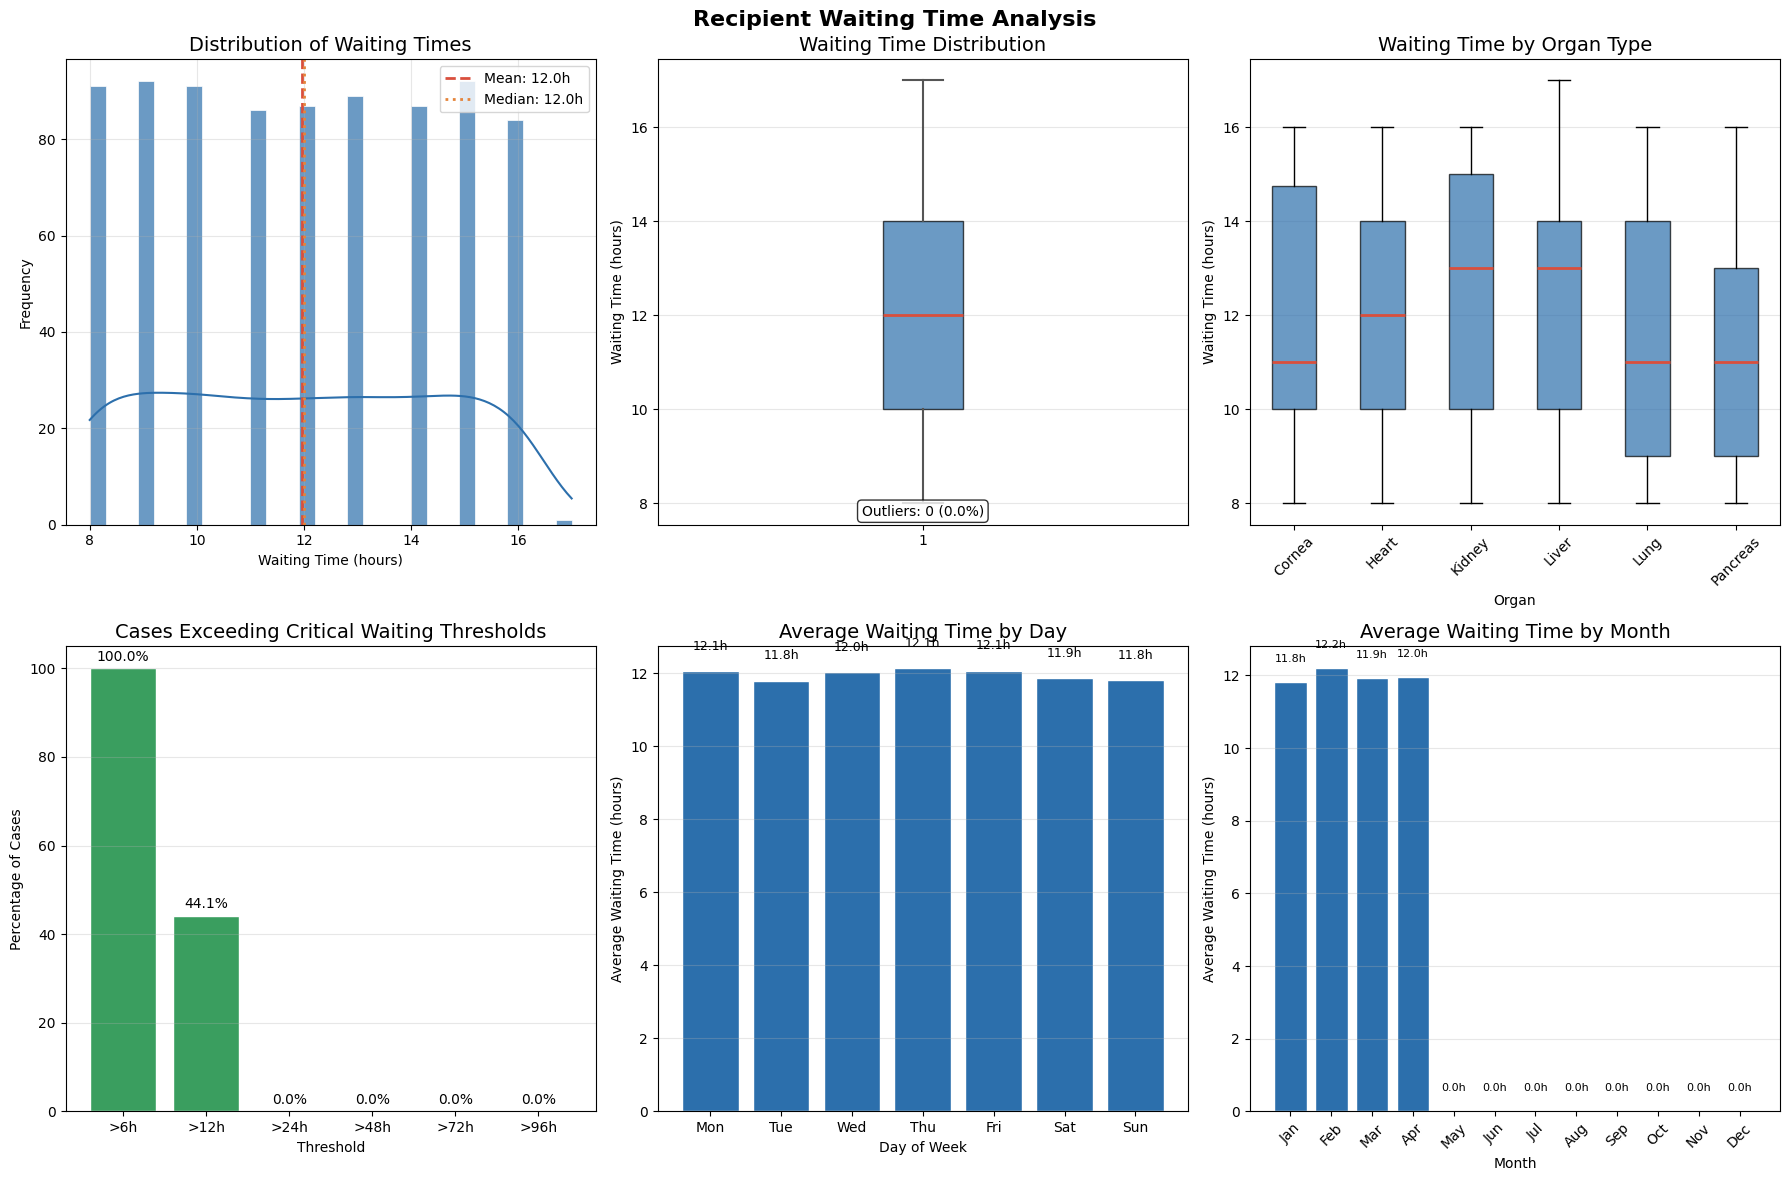


RECIPIENT WAITING TIME ANALYSIS

📊 WAITING TIME STATISTICS:
  - Mean Waiting Time: 11.96 hours
  - Median Waiting Time: 12.00 hours
  - Mode: 9 hours
  - Standard Deviation: 2.59 hours
  - Range: 8 - 17 hours
  - 25th Percentile: 10.00 hours
  - 75th Percentile: 14.00 hours

⚠️ OUTLIER ANALYSIS:
  - Number of outliers: 0 (0.0%)

🔴 CRITICAL WAITING TIMES:
  - 🔴 CRITICAL: 100.0% of recipients wait >6 hours
  - 🔴 CRITICAL: 44.1% of recipients wait >12 hours
  - ✅ ACCEPTABLE: 0.0% of recipients wait >24 hours
  - ✅ ACCEPTABLE: 0.0% of recipients wait >48 hours
  - ✅ ACCEPTABLE: 0.0% of recipients wait >72 hours
  - ✅ ACCEPTABLE: 0.0% of recipients wait >96 hours

🏥 ORGAN-SPECIFIC WAITING TIMES:
  - Kidney: Mean=12.6h, Median=13.0h, Max=16.0h
  - Heart: Mean=12.2h, Median=12.0h, Max=16.0h
  - Liver: Mean=12.2h, Median=13.0h, Max=17.0h
  - Cornea: Mean=11.9h, Median=11.0h, Max=16.0h
  - Lung: Mean=11.5h, Median=11.0h, Max=16.0h
  - Pancreas: Mean=11.3h, Median=11.0h, Max=16.0h

📅 TEMPORAL P

In [11]:
# QUESTION 9: Recipient Waiting Time Analysis

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

# Load data
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx", sheet_name="Preprocessed_Data")

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Recipient Waiting Time Analysis', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Distribution of waiting hours
ax1 = axes[0, 0]
sns.histplot(data=df, x='wait_hour', bins=30, kde=True, color='#2C6FAC', ax=ax1,
             edgecolor='white', linewidth=0.5, alpha=0.7)
ax1.axvline(df['wait_hour'].mean(), color='#D94F3D', linestyle='--', linewidth=2, 
            label=f"Mean: {df['wait_hour'].mean():.1f}h")
ax1.axvline(df['wait_hour'].median(), color='#E5843A', linestyle=':', linewidth=2, 
            label=f"Median: {df['wait_hour'].median():.1f}h")
ax1.set_title('Distribution of Waiting Times', fontsize=14)
ax1.set_xlabel('Waiting Time (hours)')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Boxplot of waiting hours
ax2 = axes[0, 1]
box = ax2.boxplot(df['wait_hour'], patch_artist=True,
                  boxprops=dict(facecolor='#2C6FAC', alpha=0.7),
                  medianprops=dict(color='#D94F3D', linewidth=2),
                  whiskerprops=dict(color='#555', linewidth=1.5),
                  capprops=dict(color='#555', linewidth=1.5),
                  flierprops=dict(marker='o', markerfacecolor='#D94F3D', alpha=0.5))
ax2.set_title('Waiting Time Distribution', fontsize=14)
ax2.set_ylabel('Waiting Time (hours)')
ax2.grid(True, alpha=0.3, axis='y')

# Add statistics
q1, q3 = np.percentile(df['wait_hour'], [25, 75])
iqr = q3 - q1
outliers = ((df['wait_hour'] < q1 - 1.5*iqr) | (df['wait_hour'] > q3 + 1.5*iqr)).sum()
ax2.text(0.5, 0.02, f'Outliers: {outliers} ({outliers/len(df)*100:.1f}%)', 
         transform=ax2.transAxes, ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 3: Waiting time by organ type
ax3 = axes[0, 2]
organ_cols = [col for col in df.columns if col.startswith('Organ_')]
organs = [col.replace('Organ_', '') for col in organ_cols]

organ_data = []
organ_labels = []
for organ in organs:
    organ_mask = df[f'Organ_{organ}'] == 1
    if organ_mask.sum() > 5:
        organ_data.append(df[organ_mask]['wait_hour'])
        organ_labels.append(organ)

bp = ax3.boxplot(organ_data, labels=organ_labels, patch_artist=True,
                 boxprops=dict(facecolor='#2C6FAC', alpha=0.7),
                 medianprops=dict(color='#D94F3D', linewidth=2))
ax3.set_title('Waiting Time by Organ Type', fontsize=14)
ax3.set_xlabel('Organ')
ax3.set_ylabel('Waiting Time (hours)')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Critical waiting time thresholds
ax4 = axes[1, 0]
thresholds = [6, 12, 24, 48, 72, 96]
critical_counts = [(df['wait_hour'] > t).sum() for t in thresholds]
critical_pcts = [c/len(df)*100 for c in critical_counts]

bars4 = ax4.bar([f'>{t}h' for t in thresholds], critical_pcts, 
                color=['#3A9E5F' if t <= 12 else '#E5843A' if t <= 24 else '#D94F3D' for t in thresholds],
                edgecolor='white', linewidth=1)
for bar, pct in zip(bars4, critical_pcts):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax4.set_title('Cases Exceeding Critical Waiting Thresholds', fontsize=14)
ax4.set_xlabel('Threshold')
ax4.set_ylabel('Percentage of Cases')
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Waiting time by day of week
ax5 = axes[1, 1]
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_data = [df[df['wait_day'] == i]['wait_hour'] for i in range(7)]
day_means = [data.mean() if len(data) > 0 else 0 for data in day_data]

bars5 = ax5.bar(day_names, day_means, color='#2C6FAC', edgecolor='white', linewidth=1)
for bar, mean in zip(bars5, day_means):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{mean:.1f}h', ha='center', va='bottom', fontsize=9)
ax5.set_title('Average Waiting Time by Day', fontsize=14)
ax5.set_xlabel('Day of Week')
ax5.set_ylabel('Average Waiting Time (hours)')
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Waiting time by month
ax6 = axes[1, 2]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_data = [df[df['wait_month'] == i]['wait_hour'] for i in range(1, 13)]
month_means = [data.mean() if len(data) > 0 else 0 for data in month_data]

bars6 = ax6.bar(month_names, month_means, color='#2C6FAC', edgecolor='white', linewidth=1)
for bar, mean in zip(bars6, month_means):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{mean:.1f}h', ha='center', va='bottom', fontsize=8)
ax6.set_title('Average Waiting Time by Month', fontsize=14)
ax6.set_xlabel('Month')
ax6.set_ylabel('Average Waiting Time (hours)')
ax6.tick_params(axis='x', rotation=45)
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed analysis
print("\n" + "="*60)
print("RECIPIENT WAITING TIME ANALYSIS")
print("="*60)

print(f"\n📊 WAITING TIME STATISTICS:")
print(f"  - Mean Waiting Time: {df['wait_hour'].mean():.2f} hours")
print(f"  - Median Waiting Time: {df['wait_hour'].median():.2f} hours")
print(f"  - Mode: {df['wait_hour'].mode()[0]:.0f} hours")
print(f"  - Standard Deviation: {df['wait_hour'].std():.2f} hours")
print(f"  - Range: {df['wait_hour'].min()} - {df['wait_hour'].max()} hours")
print(f"  - 25th Percentile: {q1:.2f} hours")
print(f"  - 75th Percentile: {q3:.2f} hours")

print(f"\n⚠️ OUTLIER ANALYSIS:")
print(f"  - Number of outliers: {outliers} ({outliers/len(df)*100:.1f}%)")
if outliers > 0:
    outlier_stats = df[df['wait_hour'] > q3 + 1.5*iqr]['wait_hour'].describe()
    print(f"  - Outlier range: {outlier_stats['min']:.1f} - {outlier_stats['max']:.1f} hours")
    print(f"  - Mean outlier time: {outlier_stats['mean']:.1f} hours")

print(f"\n🔴 CRITICAL WAITING TIMES:")
for t, pct in zip(thresholds, critical_pcts):
    status = "🔴 CRITICAL" if t <= 24 and pct > 20 else "⚠️ WARNING" if t <= 48 and pct > 10 else "✅ ACCEPTABLE"
    print(f"  - {status}: {pct:.1f}% of recipients wait >{t} hours")

print(f"\n🏥 ORGAN-SPECIFIC WAITING TIMES:")
organ_stats = []
for organ, data in zip(organ_labels, organ_data):
    organ_stats.append({
        'Organ': organ,
        'Count': len(data),
        'Mean': data.mean(),
        'Median': data.median(),
        'Max': data.max()
    })
organ_df = pd.DataFrame(organ_stats)
organ_df = organ_df.sort_values('Mean', ascending=False)
for _, row in organ_df.iterrows():
    print(f"  - {row['Organ']}: Mean={row['Mean']:.1f}h, Median={row['Median']:.1f}h, Max={row['Max']:.1f}h")

print(f"\n📅 TEMPORAL PATTERNS:")
print(f"  - Longest average wait day: {day_names[np.argmax(day_means)]} ({max(day_means):.1f}h)")
print(f"  - Shortest average wait day: {day_names[np.argmin(day_means)]} ({min(day_means):.1f}h)")
print(f"  - Longest average wait month: {month_names[np.argmax(month_means)]} ({max(month_means):.1f}h)")
print(f"  - Shortest average wait month: {month_names[np.argmin(month_means)]} ({min(month_means):.1f}h)")

print(f"\n⚠️ RECOMMENDATIONS:")
print("  - Prioritize organs for recipients with critically long waits")
print("  - Investigate causes of weekend/holiday delays")
print("  - Implement rapid response protocols for time-sensitive organs")
print("  - Create alert system for approaching critical thresholds")

Question 10: Critical Data Quality Issues

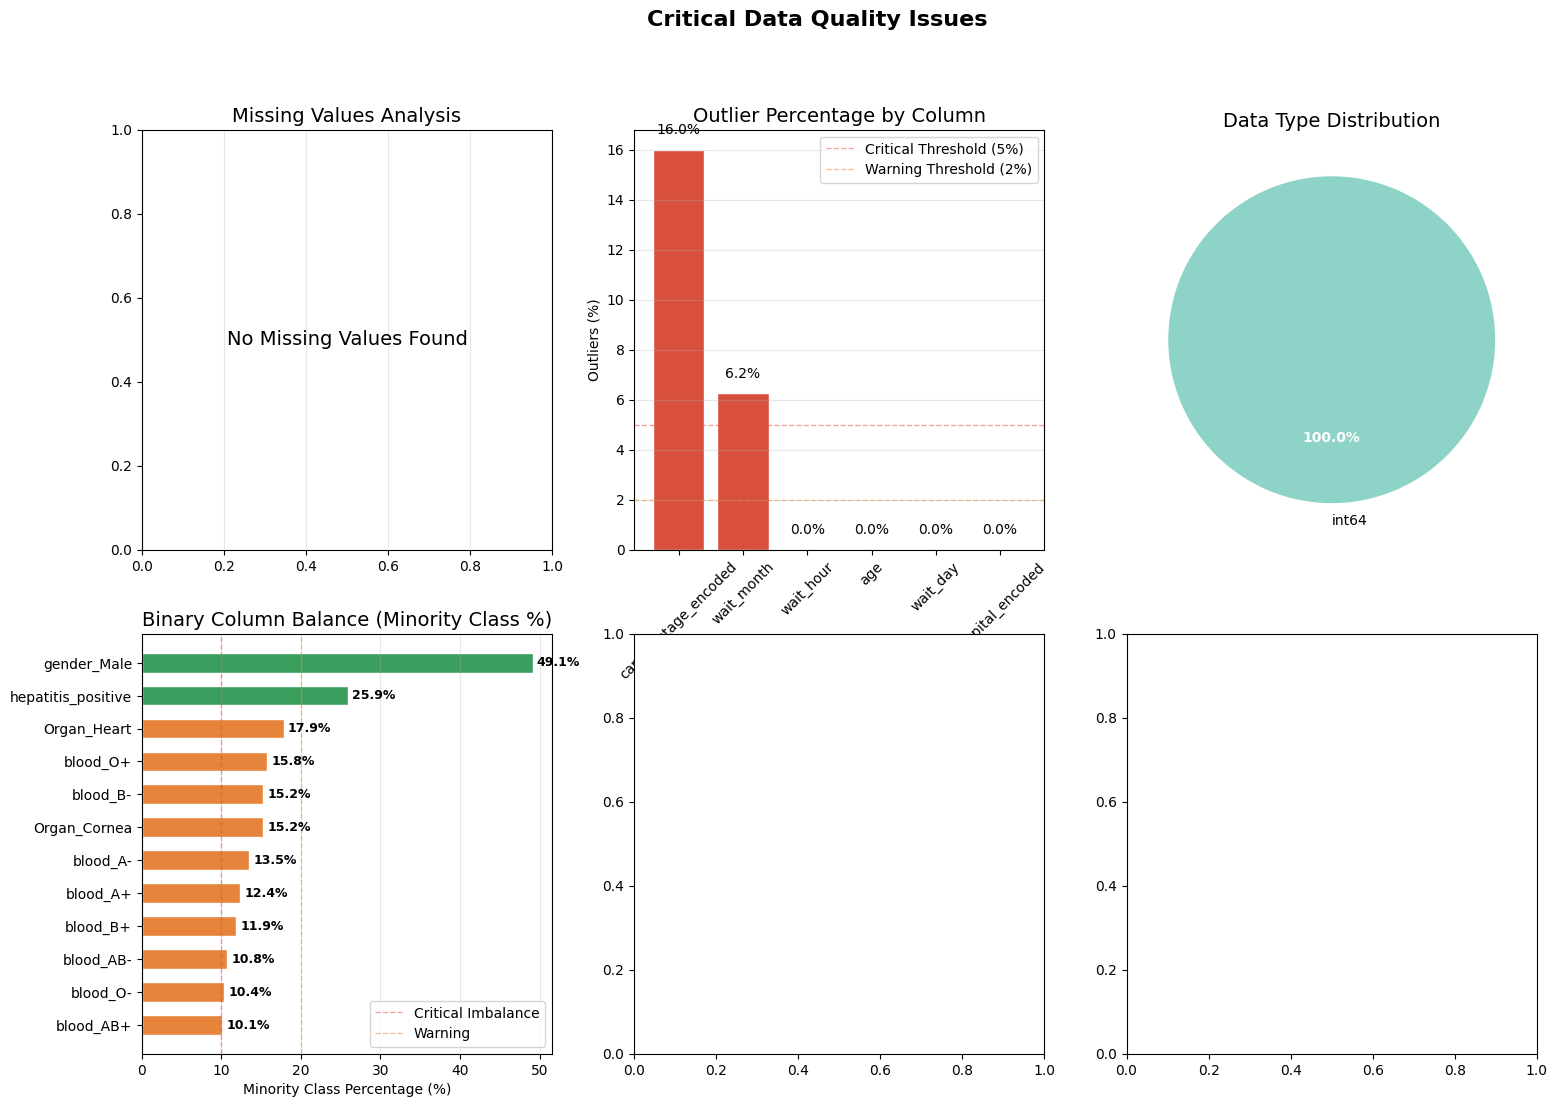

In [12]:
# QUESTION 11: Critical Data Quality Issues

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Load data
df = pd.read_excel(r"E:\final datset of opal ai\dataset\recipient_preprocessed_FINAL(opal ai).xlsx", sheet_name="Preprocessed_Data")

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Critical Data Quality Issues', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Missing values heatmap
ax1 = axes[0, 0]
missing_data = df.isnull().sum()
missing_pct = missing_data[missing_data > 0] / len(df) * 100

if len(missing_pct) > 0:
    missing_df = pd.DataFrame({'Column': missing_pct.index, 'Missing %': missing_pct.values})
    missing_df = missing_df.sort_values('Missing %', ascending=False)
    
    bars1 = ax1.barh(missing_df['Column'], missing_df['Missing %'], 
                     color='#D94F3D', edgecolor='white', height=0.6)
    for bar, pct in zip(bars1, missing_df['Missing %']):
        ax1.text(pct + 0.5, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', 
                 va='center', fontsize=10, fontweight='bold')
    ax1.set_title('Missing Values by Column', fontsize=14)
    ax1.set_xlabel('Missing Percentage (%)')
else:
    ax1.text(0.5, 0.5, 'No Missing Values Found', ha='center', va='center', 
             fontsize=14, transform=ax1.transAxes)
    ax1.set_title('Missing Values Analysis', fontsize=14)
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Outlier detection
ax2 = axes[0, 1]
numeric_cols = ['age', 'wait_hour', 'wait_day', 'wait_month', 'cancer_stage_encoded', 'hospital_encoded']
outlier_data = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    outlier_pct = outliers / len(df) * 100
    outlier_data.append({'Column': col, 'Outliers': outliers, 'Percentage': outlier_pct})

outlier_df = pd.DataFrame(outlier_data)
outlier_df = outlier_df.sort_values('Percentage', ascending=False)

bars2 = ax2.bar(outlier_df['Column'], outlier_df['Percentage'], 
                color=['#D94F3D' if p > 5 else '#E5843A' if p > 2 else '#3A9E5F' for p in outlier_df['Percentage']],
                edgecolor='white', linewidth=1)
for bar, pct in zip(bars2, outlier_df['Percentage']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
ax2.axhline(y=5, color='#D94F3D', linestyle='--', linewidth=1, alpha=0.5, label='Critical Threshold (5%)')
ax2.axhline(y=2, color='#E5843A', linestyle='--', linewidth=1, alpha=0.5, label='Warning Threshold (2%)')
ax2.set_title('Outlier Percentage by Column', fontsize=14)
ax2.set_xlabel('Column')
ax2.set_ylabel('Outliers (%)')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Data type consistency
ax3 = axes[0, 2]
dtype_counts = df.dtypes.value_counts()
colors_dtype = plt.cm.Set3(np.linspace(0, 1, len(dtype_counts)))
wedges, texts, autotexts = ax3.pie(dtype_counts.values, labels=[str(dt) for dt in dtype_counts.index], 
                                     autopct='%1.1f%%', colors=colors_dtype,
                                     startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax3.set_title('Data Type Distribution', fontsize=14)

# Plot 4: Binary column balance
ax4 = axes[1, 0]
binary_cols = [col for col in df.columns if df[col].nunique() == 2 and col not in ['gender_Male', 'hepatitis_positive']]
binary_cols = ['gender_Male', 'hepatitis_positive'] + binary_cols[:10]  # Limit to first 10

imbalance_data = []
for col in binary_cols:
    minority_pct = min(df[col].mean(), 1 - df[col].mean()) * 100
    imbalance_data.append({'Column': col, 'Minority %': minority_pct})

imbalance_df = pd.DataFrame(imbalance_data)
imbalance_df = imbalance_df.sort_values('Minority %')

bars4 = ax4.barh(imbalance_df['Column'], imbalance_df['Minority %'], 
                 color=['#D94F3D' if p < 10 else '#E5843A' if p < 20 else '#3A9E5F' for p in imbalance_df['Minority %']],
                 edgecolor='white', height=0.6)
for bar, pct in zip(bars4, imbalance_df['Minority %']):
    ax4.text(pct + 0.5, bar.get_y() + bar.get_height()/2, f'{pct:.1f}%', 
             va='center', fontsize=9, fontweight='bold')
ax4.axvline(x=10, color='#D94F3D', linestyle='--', linewidth=1, alpha=0.5, label='Critical Imbalance')
ax4.axvline(x=20, color='#E5843A', linestyle='--', linewidth=1, alpha=0.5, label='Warning')
ax4.set_title('Binary Column Balance (Minority Class %)', fontsize=14)
ax4.set_xlabel('Minority Class Percentage (%)')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='x')

# Plot 5: Duplicate detection
ax5 = axes[1, 1]
# Check for duplicate rows
duplicates = df.duplicated().sum()
dup_pct = duplicates / len(df) * 100

# Check for duplicate patient IDs if available
if 'recipient_id' in df.columns:
    id_duplicates = df['recipient_id'].duplicated().sum()
    id